# Loading Packages

In [1]:
from IPython.display import display
import ast
from general_tools.gpt_api import get_azure_client, azure_chat_completion
import json
import numpy as np
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
from PIL import Image
import os
import re

# Base Files

## Setting Up Paths

In [2]:
aux_files_path = "/home/sgw3fy/jobs/model_editing_jobs/repos/instruct_vlm_edit/aux_files"
dotenv_path = "/home/sgw3fy/jobs/model_editing_jobs/repos/instruct_vlm_edit/.env"
images_path = "/home/sgw3fy/jobs/model_editing_jobs/repos/instruct_vlm_edit/"
preds_path = "/home/sgw3fy/jobs/model_editing_jobs/repos/instruct_vlm_edit/results/pred/Qwen3-VL-4B-Instruct/aokvqa/mc_all.json"
locality_eval_path = os.path.join(aux_files_path, "locality_eval")

## Loading Base Files

In [3]:
preds_df = pd.read_json(preds_path)

In [4]:
preds_df

,uid,image,question,answer,rationale,cot,choices,idx_choices,idx,gold,prompt,pred
0,1,data/images/aokvqa/train2017/000000299207.jpg,What is the man by the bags awaiting?,cab,"A train would not be on the street, he would n...",The image shows a man standing by some bags on...,skateboarder; train; delivery; cab,(A) skateboarder\n(B) train\n(C) delivery\n(D)...,0,"{'label': 'cab', 'choices': {'str': 'skateboar...",What is the man by the bags awaiting?,{'answer': 'The man is likely awaiting a ride ...
1,2,data/images/aokvqa/train2017/000000039446.jpg,Where does this man eat pizza?,office,The man is eating pizza at a work desk in an o...,The image shows a man eating pizza. The man is...,office; cafe; motel; outside,(A) office\n(B) cafe\n(C) motel\n(D) outside,1,"{'label': 'office', 'choices': {'str': 'office...",Where does this man eat pizza?,"{'answer': 'office', 'label_text': 'office', '..."
2,3,data/images/aokvqa/train2017/000000312452.jpg,What is the occupation of the person driving?,farmer,The place is full of sheep that shows the pers...,The image shows a place full of sheep. Sheep a...,waiter; farmer; cashier; musician,(A) waiter\n(B) farmer\n(C) cashier\n(D) musician,2,"{'label': 'farmer', 'choices': {'str': 'waiter...",What is the occupation of the person driving?,"{'answer': 'shepherd', 'label_scores': {'waite..."
3,4,data/images/aokvqa/train2017/000000046408.jpg,How were the drivers of the cars able to park ...,airport workers,These drivers work at the airport.,The image shows drivers and cars parked in a s...,firemen; airport workers; police; postal workers,(A) firemen\n(B) airport workers\n(C) police\n...,3,"{'label': 'airport workers', 'choices': {'str'...",How were the drivers of the cars able to park ...,{'answer': 'The drivers of the cars were able ...
4,5,data/images/aokvqa/train2017/000000282150.jpg,How many people can ride this motorcycle at a ...,two,Two people can be on the bike.,The image shows a motorcycle with two seats. T...,four; two; three; one,(A) four\n(B) two\n(C) three\n(D) one,4,"{'label': 'two', 'choices': {'str': 'four; two...",How many people can ride this motorcycle at a ...,"{'answer': '2This is a touring motorcycle, spe..."
...,...,...,...,...,...,...,...,...,...,...,...,...
18190,18191,data/images/aokvqa/val2017/000000127092.jpg,What must be activated so the parked cars stay...,emergency brake,Cars are parked on a hill on a street.,The image shows cars parked on a hill on a str...,headlights; sunroof; radio; emergency brake,(A) headlights\n(B) sunroof\n(C) radio\n(D) em...,18190,"{'label': 'emergency brake', 'choices': {'str'...",What must be activated so the parked cars stay...,{'answer': 'The parked cars must be **braked**...
18191,18192,data/images/aokvqa/val2017/000000479030.jpg,What mechanism might all different modes of tr...,brakes,None of the other options make sense with this...,The image shows different modes of transportat...,hammer time; brakes; bat signal; voice command,(A) hammer time\n(B) brakes\n(C) bat signal\n(...,18191,"{'label': 'brakes', 'choices': {'str': 'hammer...",What mechanism might all different modes of tr...,{'answer': 'All different modes of transportat...
18192,18193,data/images/aokvqa/val2017/000000345397.jpg,What brand of hair product does he have?,head and shoulders,A dove bottle is on the shelf in the shower.,The image shows a dove bottle on a shelf in th...,finesse; dove; loreal; head and shoulders,(A) finesse\n(B) dove\n(C) loreal\n(D) head an...,18192,"{'label': 'head and shoulders', 'choices': {'s...",What brand of hair product does he have?,"{'answer': 'Based on the image provided, it is..."
18193,18194,data/images/aokvqa/val2017/000000313588.jpg,What is the pattern on the woman's coat called?,plaid,The woman's jacket is in a crisscross pattern.,The image shows a woman wearing a coat. The co...,pinstripe; polka dot; houndstooth; plaid,(A) pinstripe\n(B) polka dot\n(C) houndstooth\...,18193,"{'label': 'plaid', 'choices': {'str': 'pinstri...",What is the

## Finding Samples with Correct Predictions

In [5]:
preds_df["pred_answer"] = preds_df["pred"].apply(lambda pred: pred["label_maxprob"])

In [6]:
correct_preds_df = preds_df[preds_df["answer"] == preds_df["pred_answer"]]

In [7]:
len(correct_preds_df)

13006

## Finding samples related to occupation

In [8]:
correct_preds_df["q_occupation"] = correct_preds_df["question"].apply(lambda question: "job" in question.lower() or "occupation" in question.lower())

/tmp/ipykernel_785098/3714968877.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  correct_preds_df["q_occupation"] = correct_preds_df["question"].apply(lambda question: "job" in question.lower() or "occupation" in question.lower())


In [9]:
correct_preds_df["q_occupation"].value_counts()

q_occupation
False    12961
True        45
Name: count, dtype: int64

## Finding samples related to gender

In [10]:
correct_preds_df["q_woman"] = correct_preds_df["question"].apply(lambda question: "woman" in question.lower())
correct_preds_df["q_man"] = correct_preds_df["question"].apply(lambda question: "woman" not in question.lower() and "man" in question.lower())

/tmp/ipykernel_785098/3370869575.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  correct_preds_df["q_woman"] = correct_preds_df["question"].apply(lambda question: "woman" in question.lower())
/tmp/ipykernel_785098/3370869575.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  correct_preds_df["q_man"] = correct_preds_df["question"].apply(lambda question: "woman" not in question.lower() and "man" in question.lower())


In [11]:
correct_preds_df["q_woman"].value_counts()

q_woman
False    12505
True       501
Name: count, dtype: int64

In [12]:
correct_preds_df["q_man"].value_counts()

q_man
False    11428
True      1578
Name: count, dtype: int64

In [13]:
correct_preds_df["question"].value_counts()

question
What is he doing?                                                  16
What type of area is shown?                                        15
What type of transportation is shown?                              14
What is the man wearing?                                           14
How do these people know each other?                               13
                                                                   ..
The cat on top of the laptop possess which type of fur pattern?     1
When is this baseball game being played?                            1
What item is this animal known for?                                 1
Which one of the following animals might prey on these ones?        1
What are these pools for?                                           1
Name: count, Length: 12312, dtype: int64

In [14]:
correct_preds_df[correct_preds_df["q_man"] == 1]["question"].value_counts().loc[lambda x: x >= 2]

question
What is the man wearing?                          14
What is the man doing?                             8
What is the man holding?                           7
What does the man have in his hand?                4
What does the man have on?                         3
Why is the man wearing a yellow vest?              3
What is the man wearing on his head?               3
What is the man adjusting?                         3
What is the man taking?                            3
Why is the man wearing a glove?                    3
What is the man's profession?                      3
Where is this man located?                         3
What is the man swinging?                          3
This man looks most like what celebrity?           2
What is the man attempting to do?                  2
What is the man about to do?                       2
What does the man want to do with the ball?        2
Why does the man have his arms out?                2
What is this man's profession?       

In [15]:
correct_preds_df[correct_preds_df["q_woman"] == 1]["question"].value_counts().loc[lambda x: x >= 2]

question
What is the woman wearing?                                 9
What is the woman holding?                                 6
Why is the woman using an umbrella?                        5
What is the woman ready to do?                             5
What is the woman looking down at?                         3
What is the woman doing?                                   3
What is the woman holding in her hand?                     3
What type of shot is the woman about to hit?               3
What is the woman holding to her ear?                      2
What is the woman wearing on her head?                     2
How does the woman know the girl?                          2
Why does the woman have her arms out?                      2
What is the relationship between the man and the woman?    2
What type of hat is the woman wearing?                     2
What is the woman standing in front of?                    2
Why is the woman holding an umbrella?                      2
Where is the wo

## Creating samples for Similar Image Evaluation

### Unrelated Samples from Same question

In [16]:
import random

eval_samples = {}
question_dict = {}

valid_questions = (
    correct_preds_df[correct_preds_df["q_woman"] == 1]["question"]
    .value_counts()
    .loc[lambda x: x > 2]
    .index
)

question_idx = 0
for question in valid_questions:
    aux_correct_preds_w_df = correct_preds_df[
        (correct_preds_df["q_woman"] == 1) &
        (correct_preds_df["question"] == question)
    ]

    edit_row = aux_correct_preds_w_df.sample(n=1, random_state=123).copy()
    unrelated_rows = aux_correct_preds_w_df.drop(edit_row.index)

    # 1 save original answer
    edit_row["orig_answer"] = edit_row["answer"]

    # 2 pick a different answer from choices
    choices = [c.strip() for c in edit_row["choices"].iloc[0].split(";")]
    orig_answer = edit_row["answer"].iloc[0]
    new_choices = [c for c in choices if c != orig_answer]

    edit_row.loc[:, "answer"] = random.choice(new_choices)

    # 3 erase cot
    edit_row.loc[:, "cot"] = ""

    eval_samples[f"q{question_idx}"] = {
        "edit": edit_row,
        "unrelated": unrelated_rows
    }

    question_dict[f"q{question_idx}"] = question
    question_idx += 1

In [17]:
index = 1

In [18]:
eval_samples[f"q{index}"]["edit"]

,uid,image,question,answer,rationale,cot,choices,idx_choices,idx,gold,prompt,pred,pred_answer,q_occupation,q_woman,q_man,orig_answer
12450,12451,data/images/aokvqa/train2017/000000510572.jpg,What is the woman holding?,bunny rabbits,The woman is holding two kids.,,pumpkins; children; kittens; bunny rabbits,(A) pumpkins\n(B) children\n(C) kittens\n(D) b...,12450,"{'label': 'children', 'choices': {'str': 'pump...",What is the woman holding?,{'answer': 'The woman is holding two young chi...,children,False,True,False,children


In [19]:
eval_samples[f"q{index}"]["unrelated"]

,uid,image,question,answer,rationale,cot,choices,idx_choices,idx,gold,prompt,pred,pred_answer,q_occupation,q_woman,q_man
10447,10448,data/images/aokvqa/train2017/000000226588.jpg,What is the woman holding?,skis,The woman has skis.,The image shows a woman. The woman is holding ...,eggs; skis; shovel; bunnies,(A) eggs\n(B) skis\n(C) shovel\n(D) bunnies,10447,"{'label': 'skis', 'choices': {'str': 'eggs; sk...",What is the woman holding?,"{'answer': 'The woman is holding ski poles.', ...",skis,False,True,False
12738,12739,data/images/aokvqa/train2017/000000485014.jpg,What is the woman holding?,remote,She has as wii remote.,The image shows a woman holding an object. The...,remote; phone; ball; book,(A) remote\n(B) phone\n(C) ball\n(D) book,12738,"{'label': 'remote', 'choices': {'str': 'remote...",What is the woman holding?,{'answer': 'The woman is holding a white Ninte...,remote,False,True,False
14373,14374,data/images/aokvqa/train2017/000000393290.jpg,What is the woman holding?,plate,It has food on it and its plain white,The image shows a woman holding an object. The...,baseball bat; sword; garbage bag; plate,(A) baseball bat\n(B) sword\n(C) garbage bag\n...,14373,"{'label': 'plate', 'choices': {'str': 'basebal...",What is the woman holding?,{'answer': 'The woman is holding a white plate...,plate,False,True,False
15492,15493,data/images/aokvqa/train2017/000000242677.jpg,What is the woman holding?,dog leash,The woman is walking with a dog.,The image shows a woman and a dog. The woman i...,pumpkin pie; apple; dog leash; pizza box,(A) pumpkin pie\n(B) apple\n(C) dog leash\n(D)...,15492,"{'label': 'dog leash', 'choices': {'str': 'pum...",What is the woman holding?,{'answer': 'The woman is holding a leash attac...,dog leash,False,True,False
17641,17642,data/images/aokvqa/val2017/000000580294.jpg,What is the woman holding?,spatula,The woman uses that to flip the eggs.,The image shows a woman and eggs. The woman is...,spoon; flipper; wisk; spatula,(A) spoon\n(B) flipper\n(C) wisk\n(D) spatula,17641,"{'label': 'spatula', 'choices': {'str': 'spoon...",What is the woman holding?,{'answer': 'The woman is holding a black spatu...,spatula,False,True,False


In [20]:
with open(os.path.join(locality_eval_path, "wrong_edit_same_q.pkl"), "wb") as f:
    pkl.dump(eval_samples, f)

### Unrelated Samples from Different Questions

In [21]:
eval_samples_all_qs = {}

question_idx = 0
for question in valid_questions:
    aux_correct_preds_w_df = correct_preds_df[
        (correct_preds_df["q_woman"] == 1)
    ]

    edit_row = eval_samples[f"q{question_idx}"]["edit"]
    unrelated_rows = aux_correct_preds_w_df.drop(edit_row.index).sample(n=100, random_state=123).copy()

    eval_samples_all_qs[f"q{question_idx}"] = {
        "edit": edit_row,
        "unrelated": unrelated_rows
    }

    question_dict[f"q{question_idx}"] = question
    question_idx += 1

In [22]:
with open(os.path.join(locality_eval_path, "wrong_edit_diff_q.pkl"), "wb") as f:
    pkl.dump(eval_samples_all_qs, f)

In [23]:
len(question_dict.keys())

8

Obtain all samples w/ same question and answer

In [24]:
correct_preds_df

,uid,image,question,answer,rationale,cot,choices,idx_choices,idx,gold,prompt,pred,pred_answer,q_occupation,q_woman,q_man
1,2,data/images/aokvqa/train2017/000000039446.jpg,Where does this man eat pizza?,office,The man is eating pizza at a work desk in an o...,The image shows a man eating pizza. The man is...,office; cafe; motel; outside,(A) office\n(B) cafe\n(C) motel\n(D) outside,1,"{'label': 'office', 'choices': {'str': 'office...",Where does this man eat pizza?,"{'answer': 'office', 'label_text': 'office', '...",office,False,False,True
2,3,data/images/aokvqa/train2017/000000312452.jpg,What is the occupation of the person driving?,farmer,The place is full of sheep that shows the pers...,The image shows a place full of sheep. Sheep a...,waiter; farmer; cashier; musician,(A) waiter\n(B) farmer\n(C) cashier\n(D) musician,2,"{'label': 'farmer', 'choices': {'str': 'waiter...",What is the occupation of the person driving?,"{'answer': 'shepherd', 'label_scores': {'waite...",farmer,True,False,False
4,5,data/images/aokvqa/train2017/000000282150.jpg,How many people can ride this motorcycle at a ...,two,Two people can be on the bike.,The image shows a motorcycle with two seats. T...,four; two; three; one,(A) four\n(B) two\n(C) three\n(D) one,4,"{'label': 'two', 'choices': {'str': 'four; two...",How many people can ride this motorcycle at a ...,"{'answer': '2This is a touring motorcycle, spe...",two,False,False,True
5,6,data/images/aokvqa/train2017/000000420501.jpg,Where would one most likely see the show adver...,theater,Most likely the sign is depicting a broadway s...,The image shows a sign advertising a show. The...,theater; tv; internet; cinema,(A) theater\n(B) tv\n(C) internet\n(D) cinema,5,"{'label': 'theater', 'choices': {'str': 'theat...",Where would one most likely see the show adver...,{'answer': 'Based on the visual evidence in th...,theater,False,False,False
6,7,data/images/aokvqa/train2017/000000445368.jpg,What mood do the cows seem to be in?,happy,The cows are happy.,The image shows cows. The cows have relaxed fa...,sad; happy; curious; scared,(A) sad\n(B) happy\n(C) curious\n(D) scared,6,"{'label': 'happy', 'choices': {'str': 'sad; ha...",What mood do the cows seem to be in?,{'answer': 'The cows in the image appear to be...,happy,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18187,18188,data/images/aokvqa/val2017/000000147338.jpg,What has the fire hydrant been painted to rese...,face,It looks like a face is on it.,The image shows a fire hydrant. The fire hydra...,duck; bird; face; spongebob,(A) duck\n(B) bird\n(C) face\n(D) spongebob,18187,"{'label': 'face', 'choices': {'str': 'duck; bi...",What has the fire hydrant been painted to rese...,{'answer': 'The fire hydrant has been painted ...,face,False,False,False
18190,18191,data/images/aokvqa/val2017/000000127092.jpg,What must be activated so the parked cars stay...,emergency brake,Cars are parked on a hill on a street.,The image shows cars parked on a hill on a str...,headlights; sunroof; radio; emergency brake,(A) headlights\n(B) sunroof\n(C) radio\n(D) em...,18190,"{'label': 'emergency brake', 'choices': {'str'...",What must be activated so the parked cars stay...,{'answer': 'The parked cars must be **braked**...,emergency brake,False,False,False
18191,18192,data/images/aokvqa/val2017/000000479030.jpg,What mechanism might all different modes of tr...,brakes,None of the other options make sense with this...,The image shows different modes of transportat...,hammer time; brakes; bat signal; voice command,(A) hammer time\n(B) brakes\n(C) bat signal\n(...,18191,"{'label': 'brakes', 'choices': {'str': 'hammer...",What mechanism might all different modes of tr...,{'answer': 'All different modes of transportat...,brakes,False,False,False
18193,18194,data/images/aokvqa/val2017/000000313588.jpg,What is the pattern on the woman's coat called?,plaid,The woman's jacket is in a crisscross pattern.,The image shows a woman wearing a coat. The co.

In [25]:
correct_preds_df.columns

Index(['uid', 'image', 'question', 'answer', 'rationale', 'cot', 'choices',
       'idx_choices', 'idx', 'gold', 'prompt', 'pred', 'pred_answer',
       'q_occupation', 'q_woman', 'q_man'],
      dtype='object')

## Samples for Eval on Same Question and Same Answer | Wrong Edit

### Finding Samples

In [26]:
pair_cols = ["question", "answer"]

correct_preds_df = correct_preds_df.copy()

# tag whether a row belongs to a duplicated question-answer pair
correct_preds_df["is_duplicate_pair"] = (
    correct_preds_df.duplicated(subset=pair_cols, keep=False)
)

# assign one unique id per unique question-answer pair
correct_preds_df["question_answer_pair_id"] = (
    correct_preds_df.groupby(pair_cols, sort=False).ngroup()
)

# optional prettier ids
correct_preds_df["question_answer_pair_id"] = (
    "pair_" + correct_preds_df["question_answer_pair_id"].astype(str)
)


In [27]:
# dataset with unique pairs and their counts
unique_pairs_df = (
    correct_preds_df
    .groupby(pair_cols, as_index=False)
    .size()
    .rename(columns={"size": "n_instances"})
    .sort_values("n_instances", ascending=False)
    .reset_index(drop=True)
)

In [28]:
pair_cols = ["question", "answer"]

correct_preds_df_aux = correct_preds_df.copy()

# unique id for each unique question-answer pair
correct_preds_df_aux["qa_pair_id"] = (
    correct_preds_df_aux.groupby(pair_cols, sort=False).ngroup()
)

# number of times each pair appears
correct_preds_df_aux["qa_pair_count"] = (
    correct_preds_df_aux.groupby(pair_cols)["question"].transform("size")
)

# whether the pair is duplicated
correct_preds_df_aux["qa_pair_is_duplicate"] = correct_preds_df_aux["qa_pair_count"] > 1

### Obtaining IDs of unique pairs

In [29]:
correcunique_qa_pairs_df = (
    correct_preds_df_aux[pair_cols + ["qa_pair_id"]]
    .drop_duplicates()
    .merge(
        correct_preds_df_aux.groupby("qa_pair_id", as_index=False)
        .size()
        .rename(columns={"size": "n_instances"}),
        on="qa_pair_id",
        how="left"
    )
    .sort_values(["n_instances", "qa_pair_id"], ascending=[False, True])
    .reset_index(drop=True)
)

In [30]:
correcunique_qa_pairs_df_filtered = correcunique_qa_pairs_df[correcunique_qa_pairs_df["n_instances"] >= 5]

In [31]:
correct_preds_df_aux[correct_preds_df_aux["qa_pair_id"] == 604]

,uid,image,question,answer,rationale,cot,choices,idx_choices,idx,gold,...,pred,pred_answer,q_occupation,q_woman,q_man,is_duplicate_pair,question_answer_pair_id,qa_pair_id,qa_pair_count,qa_pair_is_duplicate
882,883,data/images/aokvqa/train2017/000000113724.jpg,What type of transportation is this?,rail,"The shape, size and design of the vehicle as w...",The image shows a vehicle and tracks. The vehi...,air; automobile; water; rail,(A) air\n(B) automobile\n(C) water\n(D) rail,882,"{'label': 'rail', 'choices': {'str': 'air; aut...",...,"{'answer': 'This is a **high-speed train**, sp...",rail,False,False,False,True,pair_604,604,8,True
6512,6513,data/images/aokvqa/train2017/000000155356.jpg,What type of transportation is this?,rail,It is moving on tracks or a railway.,The image shows tracks or a railway. The track...,air; road; water; rail,(A) air\n(B) road\n(C) water\n(D) rail,6512,"{'label': 'rail', 'choices': {'str': 'air; roa...",...,{'answer': 'This is a **train** — specifically...,rail,False,False,False,True,pair_604,604,8,True
6539,6540,data/images/aokvqa/train2017/000000056932.jpg,What type of transportation is this?,rail,This is a train which travels via the tracks o...,The image shows a train and tracks on the grou...,sky; road; rail; water,(A) sky\n(B) road\n(C) rail\n(D) water,6539,"{'label': 'rail', 'choices': {'str': 'sky; roa...",...,"{'answer': 'This is a **train**, specifically ...",rail,False,False,False,True,pair_604,604,8,True
8917,8918,data/images/aokvqa/train2017/000000404071.jpg,What type of transportation is this?,rail,The train is on traintracks.,The image shows a train and traintracks. The t...,water; rail; road; air,(A) water\n(B) rail\n(C) road\n(D) air,8917,"{'label': 'rail', 'choices': {'str': 'water; r...",...,"{'answer': 'This is a **train**, specifically ...",rail,False,False,False,True,pair_604,604,8,True
9584,9585,data/images/aokvqa/train2017/000000409105.jpg,What type of transportation is this?,rail,This is a train. the rail is on the ground.,The image shows a train. The train is position...,road; air; rail; water,(A) road\n(B) air\n(C) rail\n(D) water,9584,"{'label': 'rail', 'choices': {'str': 'road; ai...",...,"{'answer': 'This is a **train**, specifically ...",rail,False,False,False,True,pair_604,604,8,True
12700,12701,data/images/aokvqa/train2017/000000161185.jpg,What type of transportation is this?,rail,There are tracks on the ground and a train in ...,The image shows tracks on the ground. There is...,air; rail; water; road,(A) air\n(B) rail\n(C) water\n(D) road,12700,"{'label': 'rail', 'choices': {'str': 'air; rai...",...,"{'answer': 'This is a **railway system**, spec...",rail,False,False,False,True,pair_604,604,8,True
13705,13706,data/images/aokvqa/train2017/000000267203.jpg,What type of transportation is this?,rail,It's a land vehicle that uses tracks. it canno...,The image shows a land vehicle and tracks. The...,ferry; plane; car; rail,(A) ferry\n(B) plane\n(C) car\n(D) rail,13705,"{'label': 'rail', 'choices': {'str': 'ferry; p...",...,{'answer': 'This is a **train** — specifically...,rail,False,False,False,True,pair_604,604,8,True
17719,17720,data/images/aokvqa/val2017/000000316054.jpg,What type of transportation is this?,rail,The transport is by rail.,The image shows rail tracks and a train. Rail ...,road; rail; air; water,(A) road\n(B) rail\n(C) air\n(D) water,17719,"{'label': 'rail', 'choices': {'str': 'road; ra...",...,"{'answer': 'This is a **steam train**, a type ...",rail,False,False,False,True,pair_604,604,8,True


### [1 Edit] Building Edit and Unrelated Datasets for unique pairs with most cases

In [32]:
valid_questions = correcunique_qa_pairs_df_filtered["question"].to_list()
valid_qa_pair_id = correcunique_qa_pairs_df_filtered["qa_pair_id"].to_list()

In [33]:
valid_qa_pair_id

[604, 554, 1916, 430, 1377, 2956]

In [34]:
correcunique_qa_pairs_df_filtered

,question,answer,qa_pair_id,n_instances
0,What type of transportation is this?,rail,604,8
1,What type of transportation is shown?,road,554,6
2,Where is this game being played?,stadium,1916,6
3,What type of area is shown?,urban,430,5
4,How do these people know each other?,family,1377,5
5,What material is the sink made of?,stainless steel,2956,5


In [35]:
import random

eval_samples_ss = {}
question_dict_ss = {}

question_idx = 0
for question in valid_questions:
    current_qa_pair_id = correcunique_qa_pairs_df_filtered[correcunique_qa_pairs_df_filtered["question"] == question]["qa_pair_id"].iloc[0]
    aux_correct_preds_df = correct_preds_df_aux[correct_preds_df_aux["qa_pair_id"] == current_qa_pair_id]

    edit_row = aux_correct_preds_df.sample(n=1, random_state=123).copy()
    unrelated_rows = aux_correct_preds_df.drop(edit_row.index)

    # 1 save original answer
    edit_row["orig_answer"] = edit_row["answer"]

    # 2 pick a different answer from choices
    choices = [c.strip() for c in edit_row["choices"].iloc[0].split(";")]
    orig_answer = edit_row["answer"].iloc[0]
    new_choices = [c for c in choices if c != orig_answer]

    edit_row.loc[:, "answer"] = random.choice(new_choices)

    # 3 erase cot
    edit_row.loc[:, "cot"] = ""

    eval_samples_ss[f"q{question_idx}"] = {
        "edit": edit_row,
        "unrelated": unrelated_rows
    }

    question_dict_ss[f"q{question_idx}"] = question
    question_idx += 1

In [36]:
with open(os.path.join(locality_eval_path, "wrong_edit_same_qa.pkl"), "wb") as f:
    pkl.dump(eval_samples_ss, f)

In [37]:
with open(os.path.join(locality_eval_path, "question_dict_same_qa.pkl"), "wb") as f:
    pkl.dump(question_dict_ss, f)

In [38]:
index = 4

In [39]:
eval_samples_ss[f"q{index}"]["edit"]

,uid,image,question,answer,rationale,cot,choices,idx_choices,idx,gold,...,pred_answer,q_occupation,q_woman,q_man,is_duplicate_pair,question_answer_pair_id,qa_pair_id,qa_pair_count,qa_pair_is_duplicate,orig_answer
3257,3258,data/images/aokvqa/train2017/000000491279.jpg,How do these people know each other?,coworkers,The woman has two daughters and they all resem...,,teammates; coworkers; family; classmates,(A) teammates\n(B) coworkers\n(C) family\n(D) ...,3257,"{'label': 'family', 'choices': {'str': 'teamma...",...,family,False,False,False,True,pair_1377,1377,5,True,family


In [40]:
eval_samples_ss[f"q{index}"]["unrelated"]

,uid,image,question,answer,rationale,cot,choices,idx_choices,idx,gold,...,pred,pred_answer,q_occupation,q_woman,q_man,is_duplicate_pair,question_answer_pair_id,qa_pair_id,qa_pair_count,qa_pair_is_duplicate
1971,1972,data/images/aokvqa/train2017/000000128647.jpg,How do these people know each other?,family,They look like they're related.,The image shows people with similar facial fea...,classmates; acquaintances; family; coworkers,(A) classmates\n(B) acquaintances\n(C) family\...,1971,"{'label': 'family', 'choices': {'str': 'classm...",...,{'answer': 'Based on the visual cues in the im...,family,False,False,False,True,pair_1377,1377,5,True
5138,5139,data/images/aokvqa/train2017/000000090594.jpg,How do these people know each other?,family,Given the familiarity and comfort of this chil...,The image shows a child and an adult. The chil...,rivals; coworkers; teammates; family,(A) rivals\n(B) coworkers\n(C) teammates\n(D) ...,5138,"{'label': 'family', 'choices': {'str': 'rivals...",...,"{'answer': 'Based on the image, the most likel...",family,False,False,False,True,pair_1377,1377,5,True
9795,9796,data/images/aokvqa/train2017/000000250893.jpg,How do these people know each other?,family,The exact relationship is impossible to tell f...,The image shows a group of people in a home se...,coworkers; teammates; classmates; family,(A) coworkers\n(B) teammates\n(C) classmates\n...,9795,"{'label': 'family', 'choices': {'str': 'cowork...",...,{'answer': 'Based on the visual evidence in th...,family,False,False,False,True,pair_1377,1377,5,True
11758,11759,data/images/aokvqa/train2017/000000236623.jpg,How do these people know each other?,family,The girl appears to be the adult's daughter.,The image shows a girl and an adult. The girl ...,teammates; coworkers; neighbors; family,(A) teammates\n(B) coworkers\n(C) neighbors\n(...,11758,"{'label': 'family', 'choices': {'str': 'teamma...",...,"{'answer': 'Based on the image, it’s highly li...",family,False,False,False,True,pair_1377,1377,5,True


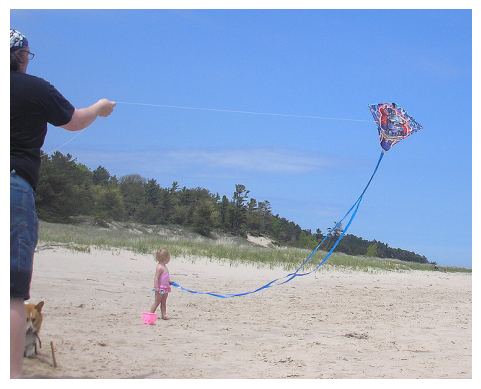

In [44]:
img = Image.open(os.path.join(images_path, "data/images/aokvqa/train2017/000000236623.jpg"))
plt.imshow(img)
plt.axis("off")
plt.show()

### [N Edit] Building Edit and Unrelated Datasets for unique pairs with most cases

In [60]:
n_edits = 3

In [61]:
eval_samples_n_edits_qa = {}
question_dict_n_edits_qa = {}

question_idx = 0
for question in valid_questions:
    current_qa_pair_id = correcunique_qa_pairs_df_filtered[
        correcunique_qa_pairs_df_filtered["question"] == question
    ]["qa_pair_id"].iloc[0]

    aux_correct_preds_df = correct_preds_df_aux[
        correct_preds_df_aux["qa_pair_id"] == current_qa_pair_id
    ].copy()

    current_n_edits = min(n_edits, len(aux_correct_preds_df))

    edit_rows = aux_correct_preds_df.sample(n=current_n_edits, random_state=123).copy()
    unrelated_rows = aux_correct_preds_df.drop(edit_rows.index).copy()

    # 1 save original answer
    edit_rows["orig_answer"] = edit_rows["answer"]

    # 2 pick a different answer from choices for each sampled row
    for idx in edit_rows.index:
        choices = [c.strip() for c in edit_rows.loc[idx, "choices"].split(";")]
        orig_answer = edit_rows.loc[idx, "answer"]
        new_choices = [c for c in choices if c != orig_answer]

        if len(new_choices) == 0:
            continue

        edit_rows.loc[idx, "answer"] = random.choice(new_choices)

    # 3 erase cot
    edit_rows.loc[:, "cot"] = ""

    eval_samples_n_edits_qa[f"q{question_idx}"] = {
        "edit": edit_rows,
        "unrelated": unrelated_rows
    }

    question_dict_n_edits_qa[f"q{question_idx}"] = question
    question_idx += 1

In [62]:
index = 3

In [63]:
eval_samples_n_edits_qa[f"q{index}"]["edit"]

,uid,image,question,answer,rationale,cot,choices,idx_choices,idx,gold,...,pred_answer,q_occupation,q_woman,q_man,is_duplicate_pair,question_answer_pair_id,qa_pair_id,qa_pair_count,qa_pair_is_duplicate,orig_answer
4626,4627,data/images/aokvqa/train2017/000000480587.jpg,What type of area is shown?,rural,This is a more crowded area.,,coastal; rural; urban; forest,(A) coastal\n(B) rural\n(C) urban\n(D) forest,4626,"{'label': 'urban', 'choices': {'str': 'coastal...",...,urban,False,False,False,True,pair_430,430,5,True,urban
11635,11636,data/images/aokvqa/train2017/000000021926.jpg,What type of area is shown?,beach,There are lots of people and buildings close t...,,coastal; beach; urban; rural,(A) coastal\n(B) beach\n(C) urban\n(D) rural,11635,"{'label': 'urban', 'choices': {'str': 'coastal...",...,urban,False,False,False,True,pair_430,430,5,True,urban
13599,13600,data/images/aokvqa/train2017/000000105647.jpg,What type of area is shown?,coastal,"With the buildings and traffic, that would be ...",,urban; rural; forest; coastal,(A) urban\n(B) rural\n(C) forest\n(D) coastal,13599,"{'label': 'urban', 'choices': {'str': 'urban; ...",...,urban,False,False,False,True,pair_430,430,5,True,urban


In [64]:
eval_samples_n_edits_qa[f"q{index}"]["unrelated"]

,uid,image,question,answer,rationale,cot,choices,idx_choices,idx,gold,...,pred,pred_answer,q_occupation,q_woman,q_man,is_duplicate_pair,question_answer_pair_id,qa_pair_id,qa_pair_count,qa_pair_is_duplicate
625,626,data/images/aokvqa/train2017/000000015110.jpg,What type of area is shown?,urban,The tall buildings and street lights gives it ...,The image shows tall buildings and street ligh...,forest; urban; coastal; rural,(A) forest\n(B) urban\n(C) coastal\n(D) rural,625,"{'label': 'urban', 'choices': {'str': 'forest;...",...,"{'answer': 'urban', 'label_text': 'urban', 'la...",urban,False,False,False,True,pair_430,430,5,True
7330,7331,data/images/aokvqa/train2017/000000401312.jpg,What type of area is shown?,urban,"Urban areas are in cities, places with high po...",The image shows skyscrapers and highways. Skys...,rural; tropical; urban; arctic,(A) rural\n(B) tropical\n(C) urban\n(D) arctic,7330,"{'label': 'urban', 'choices': {'str': 'rural; ...",...,"{'answer': 'urban', 'label_text': 'urban', 'la...",urban,False,False,False,True,pair_430,430,5,True


In [65]:
with open(os.path.join(locality_eval_path, f"wrong_{n_edits}_edits_same_qa.pkl"), "wb") as f:
    pkl.dump(eval_samples_n_edits_qa, f)

In [ ]:
with open(os.path.join(locality_eval_path, "wrong_edit_same_qa.pkl"), "wb") as f:
    pkl.dump(eval_samples_ss, f)

In [ ]:
with open(os.path.join(locality_eval_path, "question_dict_same_qa.pkl"), "wb") as f:
    pkl.dump(question_dict_ss, f)

In [ ]:
index = 3

In [ ]:
eval_samples_ss[f"q{index}"]["edit"]

,uid,image,question,answer,rationale,cot,choices,idx_choices,idx,gold,...,pred_answer,q_occupation,q_woman,q_man,is_duplicate_pair,question_answer_pair_id,qa_pair_id,qa_pair_count,qa_pair_is_duplicate,orig_answer
4626,4627,data/images/aokvqa/train2017/000000480587.jpg,What type of area is shown?,forest,This is a more crowded area.,,coastal; rural; urban; forest,(A) coastal\n(B) rural\n(C) urban\n(D) forest,4626,"{'label': 'urban', 'choices': {'str': 'coastal...",...,urban,False,False,False,True,pair_430,430,5,True,urban


In [ ]:
eval_samples_ss[f"q{index}"]["unrelated"]

,uid,image,question,answer,rationale,cot,choices,idx_choices,idx,gold,...,pred,pred_answer,q_occupation,q_woman,q_man,is_duplicate_pair,question_answer_pair_id,qa_pair_id,qa_pair_count,qa_pair_is_duplicate
625,626,data/images/aokvqa/train2017/000000015110.jpg,What type of area is shown?,urban,The tall buildings and street lights gives it ...,The image shows tall buildings and street ligh...,forest; urban; coastal; rural,(A) forest\n(B) urban\n(C) coastal\n(D) rural,625,"{'label': 'urban', 'choices': {'str': 'forest;...",...,"{'answer': 'urban', 'label_text': 'urban', 'la...",urban,False,False,False,True,pair_430,430,5,True
7330,7331,data/images/aokvqa/train2017/000000401312.jpg,What type of area is shown?,urban,"Urban areas are in cities, places with high po...",The image shows skyscrapers and highways. Skys...,rural; tropical; urban; arctic,(A) rural\n(B) tropical\n(C) urban\n(D) arctic,7330,"{'label': 'urban', 'choices': {'str': 'rural; ...",...,"{'answer': 'urban', 'label_text': 'urban', 'la...",urban,False,False,False,True,pair_430,430,5,True
11635,11636,data/images/aokvqa/train2017/000000021926.jpg,What type of area is shown?,urban,There are lots of people and buildings close t...,The image shows people and buildings. There ar...,coastal; beach; urban; rural,(A) coastal\n(B) beach\n(C) urban\n(D) rural,11635,"{'label': 'urban', 'choices': {'str': 'coastal...",...,{'answer': 'This image shows an amusement park...,urban,False,False,False,True,pair_430,430,5,True
13599,13600,data/images/aokvqa/train2017/000000105647.jpg,What type of area is shown?,urban,"With the buildings and traffic, that would be ...",The image shows buildings and traffic. Buildin...,urban; rural; forest; coastal,(A) urban\n(B) rural\n(C) forest\n(D) coastal,13599,"{'label': 'urban', 'choices': {'str': 'urban; ...",...,{'answer': 'This image shows a bustling urban ...,urban,False,False,False,True,pair_430,430,5,True


### 

In [ ]:
row = correct_preds_w_df[(correct_preds_w_df["question"] == question)].iloc[index]

img = Image.open(os.path.join(images_path, row["image"]))
question = row["question"]
answer = row["answer"]
choices = row["choices"]

plt.imshow(img)
plt.title(question + " " + answer + " \n" + choices)
plt.axis("off")
plt.show()

In [126]:
valid_questions = (
    correct_preds_df[correct_preds_df["q_woman"] == 1]["question"]
    .value_counts()
    .loc[lambda x: x >= 2]
    .index
)

correct_preds_w_df = correct_preds_df[
    (correct_preds_df["q_woman"] == 1) &
    (correct_preds_df["question"].isin(valid_questions))
]

In [123]:
index = 2
question = valid_questions[3]

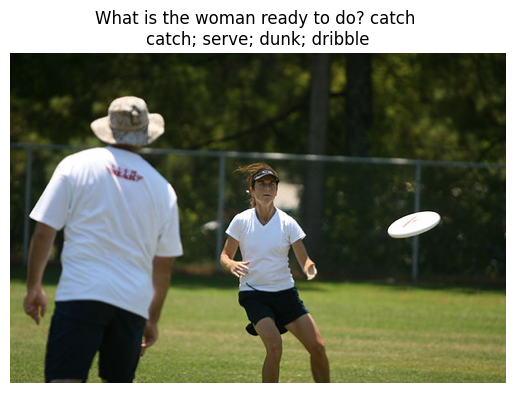

In [124]:
row = correct_preds_w_df[(correct_preds_w_df["question"] == question)].iloc[index]

img = Image.open(os.path.join(images_path, row["image"]))
question = row["question"]
answer = row["answer"]
choices = row["choices"]

plt.imshow(img)
plt.title(question + " " + answer + " \n" + choices)
plt.axis("off")
plt.show()

### Man